# Mapping the Narrative Journey: A Structural Analysis of Podcast Conversations

**Notebook:** Initial analysis, testing, and implementation of semantic segmentation and topic modeling pipelines.

**Dataset:** SPoRC (Podcast Corpus)

**Goal:** Develop and evaluate methods to segment podcast transcripts into coherent narrative units.

## Setup

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
nltk.download("punkt")
from sentence_transformers import SentenceTransformer, util
from wtpsplit import SaT
import torch

# For topic modeling, graph modeling, visualization
from sklearn.cluster import KMeans
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import networkx as nx
import plotly.graph_objects as go

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sadik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Analytical Pipeline

**This is an analysis project that applies a sequence of existing NLP techniques to generate novel insights.**

- **Semantic Segmentation:** Transcripts will first be divided into coherent topical segments using text similarity algorithms, identifying natural breakpoints in the conversation.

- **Topic Labeling:** Each segment will be assigned a concise topic label using a powerful topic modeling technique like BERTopic or a Large Language Model for high-quality, human-readable labels.

- **Graph Modeling:** The sequence of topics will be modeled as a directed graph, where nodes represent topics and weighted edges represent the transitions between them. The NetworkX library can be an option for this analysis.

- **Visualization:** The conversational journey will be visualized using topic-flow diagrams (e.g., Sankey diagrams) and graph plots to make the narrative structure intuitive and easy to interpret.

---

Following sections will follow this pipeline Starting with ***Loading the dataset***

## Load and Explore Data

#### Load the full SPoRC dataset

In [ ]:
# Load the SPoRC dataset (12G!)
# too big ! using sampledata instead
# dataset = load_dataset("blitt/SPoRC")

#### Load sample subset of the SPoRC dataset

In [8]:
# Path to your sample file
file_path_episode = r"C:\Users\Sadik\Desktop\NLP Project\episodeLevelDataSample.jsonl"
file_path_spkr = r"C:\Users\Sadik\Desktop\NLP Project\speakerTurnDataSample.jsonl"
dataset_sample = pd.read_json(file_path_episode, lines=True) # Reads JSONL line by line
spkr_data = pd.read_json(file_path_spkr, lines=True)

In [12]:
# print(f"Number of episodes: {len(dataset_sample)}")
# print(f"Columns: \n{list(dataset_sample.columns)}")
dataset_sample.head(2)
#dataset_sample.info()
# spkr_data.head()

,transcript,rssUrl,epTitle,epDescription,mp3url,podTitle,lastUpdate,itunesAuthor,itunesOwnerName,explicit,...,neitherPredictedNames,numUniqueNeithers,mainEpSpeakers,numMainSpeakers,hostSpeakerLabels,guestSpeakerLabels,overlapPropTurnCount,avgTurnDuration,overlapPropDuration,totalSpLabels
0,I'm Simon Shapiro and this is Sing Out Speak ...,https://feeds.buzzsprout.com/783020.rss,Best of SingOut SpeakOut No.3,<p>Best of with snippets from 3 episodes and a...,https://www.buzzsprout.com/783020/4252475-best...,SingOut SpeakOut,1607561074,Simon Shapiro,Simon Shapiro,0,...,NO_NEITHER_IDENTIFIED,0,[SPEAKER_00],1.0,{'Simon Shapiro': 'SPEAKER_00'},SPEAKER_DATA_UNAVAILABLE,0.0,60.0,0.0,1.0
1,I'm Simon Shapiro and this is Sing Out Speak ...,https://feeds.buzzsprout.com/783020.rss,It's All Gone,<p>Simon introduces &apos;It&apos;s all Gone&a...,https://www.buzzsprout.com/783020/4165286-it-s...,SingOut SpeakOut,1607561074,Simon Shapiro,Simon Shapiro,0,...,NO_NEITHER_IDENTIFIED,0,"[SPEAKER_00, SPEAKER_01, SPEAKER_02]",3.0,{'Simon Shapiro': 'SPEAKER_00'},SPEAKER_DATA_UNAVAILABLE,0.0,120.053333,0.0,3.0


#### Preview transcript

In [ ]:
#spkr_data.iloc[7]['turnText']
#spkr_data.head() scdw cdemdwegr32

In [127]:
episode = dataset_sample.iloc[3]["transcript"] # the first episodes transcript
# print(f"Transcript sample: {episode[:500]}...") # preview the first 500 chars
print(f" Total length of the transcript: {len(episode)}")

# description = dataset_sample.iloc[0]['epDescription']
# description
episode

 Total length of the transcript: 3121


" I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me. My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out. Hi I hope you're having a fantastic week everyone. Thank you to all those who tuned in last week and listen to the first song from the Keystone album Way to Know Where. I'm very proud of the whole album and how it's turned out and the response that we're getting through iTunes and Spotify and all those kind of other places and etc. So I do have some new music that is purely my own coming very soon and that is in the works. I promise you. In the meantime I'm going to keep on delivering some of the Keystone Chunes. So week two and I'm also honing my skills with this video thing so let's see if I've improved at 

## Semantic Segmentation Functions

**In this section we will test multiple segmentation operation using:**
1. `wtpsplit` and `SentenceTransformer`
2. `punkt(e.g. sent_tokenize)` and `SentenceTransformer`
3. unsupervised `TextTiling Algorithm` from *[unsupervised_topic_segmentation](https://github.com/gdamaskinos/unsupervised_topic_segmentation)*

### 1. Testing segmentation with `wtpsplit` and `SentenceTransformer`

In [132]:

def create_topical_segments(sents, embedding_model, window=3, prominence=0.05, drop_factor=0.85):
    """
    This is the "segment_adaptive" logic, but modified to accept a
    list of pre-split sentences (from wtpsplit) instead of raw text.
    
    This function finds the *thematic* breaks.
    """
    
    print(f"\nAnalyzing {len(sents)} sentences for *topical* breaks...")
    
    if len(sents) < 2: 
        return [" ".join(sents)], [], []
        
    # --- 1. Get Embeddings ---
    # We use the embedding_model (e.g., 'all-mpnet-base-v2') for this
    print("Calculating sentence embeddings...")
    embs = embedding_model.encode(sents, show_progress_bar=True)
    
    # --- 2. Calculate Adjacent Similarities ---
    print("Calculating adjacent sentence similarities...")
    sim = [util.cos_sim(embs[i], embs[i + 1]).item() for i in range(len(embs) - 1)]
    
    # --- 3. Smooth, Invert, and Find Peaks ---
    print("Smoothing signal and finding peaks (topic breaks)...")
    # Use a longer window to find bigger "paragraph" level breaks
    smooth = np.convolve(sim, np.ones(window)/window, mode="same")
    inverted = 1 - np.array(smooth)
    
    # Find peaks with a minimum prominence
    peaks, _ = find_peaks(inverted, prominence=prominence)
    
    # --- 4. Adaptive Filtering ---
    # Filter peaks to only keep "significant" drops
    mean_sim = np.mean(smooth)
    adaptive_threshold = drop_factor * mean_sim
    
    breaks = [p for p in peaks if smooth[p] < adaptive_threshold]
    
    print(f"Raw similarity scores (sample): {[round(s, 2) for s in sim[:5]]}...")
    print(f"Smoothed signal (sample): {[round(s, 2) for s in smooth[:5]]}...")
    print(f"Found {len(peaks)} local peaks (potential breaks).")
    print(f"Adaptive threshold is: {adaptive_threshold:.4f}")
    print(f"Filtered down to {len(breaks)} significant topical breaks.")

    # --- 5. Create Final Segments ---
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    
    return segs, smooth, peaks


In [133]:
print("Loading 'sat-12l-sm' (wtpsplit) model...")
sat_model = SaT("sat-12l-sm")

# Move to GPU if available
try:
    if torch.cuda.is_available():
        print("CUDA available. Moving SaT to GPU.")
        sat_model.to("cuda")
        sat_model.half()
    else:
        print("SaT running on CPU.")
except Exception as e:
    print(f"GPU setup for SaT failed: {e}")
# --- Load Model 2: The Embedding Model (SentenceTransformer) ---
print("Loading 'all-mpnet-base-v2' (embedding) model...")
# This model is specifically designed to be good at semantic similarity
embed_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
print("All models loaded.")
# --- Sample Data ---
sample_transcript = (
    "Welcome to 'TechForward', I'm your host, Alex. Today we're diving deep into the world of artificial intelligence. "
    "It's a field that's moving at lightning speed. Just last year, we saw models that could write poetry, and now we're seeing AI that can generate photorealistic video. "
    "It's truly a paradigm shift in content creation.\n"
    "But what does this mean for artists and creators? "
    "Many are worried about their jobs being automated. Sarah, you're an expert in AI ethics, what's your take? "
    "Well Alex, it's a valid concern, but I see it more as a tool for augmentation, not replacement. "
    "Think of it like the synthesizer in music - it didn't replace musicians, it created new genres.\n"
    "That's a great point. Let's switch gears a bit. I want to talk about hardware. "
    "None of this amazing AI would be possible without the incredible advancements in GPU technology. "
    "These new tensor cores are specifically designed for matrix multiplication, which is the heart of deep learning. "
    "It's fascinating how software and hardware are co-evolving.\n"
    "Speaking of hardware, I've just been testing the new 'QuantumByte' laptop. "
    "It's got one of these new chips, and the performance is just staggering for such a thin device. "
    "The battery life, however, is another story. I'm getting about half of what they advertised. "
    "That's always the trade-off, isn't it? Power versus longevity. "
    "For our listeners thinking of upgrading, I'd say wait for the second-gen reviews.\n"
    "Absolutely. Okay, before we wrap up, let's look at what's coming next week. "
    "We'll be interviewing the CEO of 'GreenSolar', a company revolutionizing home energy storage. "
    "They claim their new battery technology can power a home for three days straight. "
    "It's a bold claim, and we're going to dig into the science behind it. Thanks for tuning in."
)
# --- STEP 1: Get clean sentences from wtpsplit ---
# We use do_paragraph_segmentation=False to just get *sentences*
print("\n--- STEP 1: Cleaning text with wtpsplit ---")
# --- interchangeably testing with episode data and sample data (e.g. sample_transcript) 
clean_sentences = sat_model.split(episode, do_paragraph_segmentation=False)
print(f"Successfully split text into {len(clean_sentences)} clean sentences.")
# --- STEP 2: Find topical segments from the clean sentences ---
print("\n--- STEP 2: Finding topical segments with adaptive method ---")
# We can tune these parameters. A larger 'window' (e.g., 5) and
# a larger 'prominence' (e.g., 0.1) will find *fewer* and *larger* segments.
topic_segments, _, _ = create_topical_segments(
    clean_sentences, 
    embed_model,
    window=3, 
    prominence=0.05, 
    drop_factor=0.85
)
# --- Print Final Results ---
print("\n" + "="*30)
print("ROBUST TOPICAL SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(topic_segments):
    print(f"--- TOPICAL SEGMENT {i+1} ---\n")
    print(segment.strip())
    print("\n" + "-"*20 + "\n")

Loading 'sat-12l-sm' (wtpsplit) model...
CUDA available. Moving SaT to GPU.
Loading 'all-mpnet-base-v2' (embedding) model...
All models loaded.

--- STEP 1: Cleaning text with wtpsplit ---
Successfully split text into 30 clean sentences.

--- STEP 2: Finding topical segments with adaptive method ---

Analyzing 30 sentences for *topical* breaks...
Calculating sentence embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Calculating adjacent sentence similarities...
Smoothing signal and finding peaks (topic breaks)...
Raw similarity scores (sample): [0.41, 0.45, 0.25, 0.24, 0.19]...
Smoothed signal (sample): [0.29, 0.37, 0.32, 0.23, 0.29]...
Found 3 local peaks (potential breaks).
Adaptive threshold is: 0.2298
Filtered down to 2 significant topical breaks.

ROBUST TOPICAL SEGMENTATION RESULTS

--- TOPICAL SEGMENT 1 ---

I'm Simon Shapiro and this is Sing Out Speak Out.  Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me.  My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out.  Hi  I hope you're having a fantastic week everyone.  Thank you to all those who tuned in last week and listen to the first song from the Keystone album Way to Know Where.  I'm very proud of the whole album an

### 2. Testing Segmentation with `punkt(e.g. sent_tokenize)` and `SentenceTransformer`

In [134]:
#model = SentenceTransformer("all-MiniLM-L6-v2") #medium
model = SentenceTransformer("all-mpnet-base-v2") #large

In [129]:
def segment_fixed_threshold(text, model, percentile_threshold=25):
    sents = sent_tokenize(text)
    if len(sents) < 2: 
        return [text], []
    embs = model.encode(sents)
    sim = [cosine_similarity([embs[i]], [embs[i + 1]])[0][0] for i in range(len(embs) - 1)]
    threshold = np.percentile(sim, percentile_threshold)    #a different approach
    breaks = [i + 1 for i, sc in enumerate(sim) if sc < threshold]
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    return segs, sim


def segment_adaptive(text, model, window=3, prominence=0.05, drop_factor=0.85):
    sents = sent_tokenize(text)
    if len(sents) < 2: 
        return [text], [], []
    embs = model.encode(sents)
    sim = [cosine_similarity([embs[i]], [embs[i + 1]])[0][0] for i in range(len(embs) - 1)]
    smooth = np.convolve(sim, np.ones(window)/window, mode="same")
    inverted = 1 - np.array(smooth)
    peaks, _ = find_peaks(inverted, prominence=prominence)
    breaks = [p for p in peaks if smooth[p] < drop_factor * np.mean(smooth)]
    idx = [0] + breaks + [len(sents)]
    segs = [" ".join(sents[idx[i]:idx[i + 1]]) for i in range(len(idx) - 1)]
    return segs, smooth, peaks


def segment_coherence(segments, model):
    vals = []
    for seg in segments:
        sents = sent_tokenize(seg)
        if len(sents) < 2: 
            continue
        embs = model.encode(sents)
        sims = [cosine_similarity([embs[i]], [embs[j]])[0][0]
                for i in range(len(embs)) for j in range(i + 1,len(embs))]
        vals.append(np.mean(sims))
    return np.mean(vals) if vals else 0

def plot_similarity_curve(sim_scores, peaks=None, title="Similarity Curve"):
    plt.figure(figsize=(8, 4))
    plt.plot(sim_scores, label="Semantic Similarity")

    if peaks is not None and len(peaks) > 0:
        plt.scatter(peaks, np.array(sim_scores)[peaks], color='red', label='Detected Boundaries')
    
    plt.title(title)
    plt.xlabel("Sentence index")
    plt.ylabel("Cosine similarity")
    plt.legend()
    plt.show()

### Testing the hyper parameter for the `segment_adaptive` version

In [96]:
sample_text = episode
win = [[2, 2, 2, 2, 2, 2], [3, 3, 3, 3, 3, 3], [4, 4, 4, 4, 4, 4], [5, 5, 5, 5, 5, 5], [6, 6, 6, 6, 6, 6]]
prom = [0.06, 0.07, 0.08, 0.09, 0.1]
for j in range(len(win)):
    for i, (window, prominence) in enumerate(zip(win[j], prom), start=1):
        segments, _, _ = segment_adaptive(sample_text, model, window, prominence)
        print(f"{5*'-'} Test {j} {5*'-'}\nAdaptive coherence: {segment_coherence(segments, model):.3f}\n")

----- Test 0 -----
Adaptive coherence: 0.246

----- Test 0 -----
Adaptive coherence: 0.246

----- Test 0 -----
Adaptive coherence: 0.246

----- Test 0 -----
Adaptive coherence: 0.246

----- Test 0 -----
Adaptive coherence: 0.243

----- Test 1 -----
Adaptive coherence: 0.234

----- Test 1 -----
Adaptive coherence: 0.226

----- Test 1 -----
Adaptive coherence: 0.222

----- Test 1 -----
Adaptive coherence: 0.216

----- Test 1 -----
Adaptive coherence: 0.214

----- Test 2 -----
Adaptive coherence: 0.202

----- Test 2 -----
Adaptive coherence: 0.200

----- Test 2 -----
Adaptive coherence: 0.202

----- Test 2 -----
Adaptive coherence: 0.201

----- Test 2 -----
Adaptive coherence: 0.200

----- Test 3 -----
Adaptive coherence: 0.204

----- Test 3 -----
Adaptive coherence: 0.204

----- Test 3 -----
Adaptive coherence: 0.201

----- Test 3 -----
Adaptive coherence: 0.201

----- Test 3 -----
Adaptive coherence: 0.198

----- Test 4 -----
Adaptive coherence: 0.197

----- Test 4 -----
Adaptive cohere

### Testing the hyper parameter for the `segment_fixed_threshold` version

In [ ]:
sample_text = episode
percentile_threshold = [5, 10, 15, 20, 25, 30, 40, 45, 50, 55, 60, 70, 80, 90]
for i, percentile in enumerate(percentile_threshold, start=1):
    segments, _ = segment_fixed_threshold(sample_text, model, percentile)
    print(f"{5*'-'} Test {i} {5*'-'}\nAdaptive coherence: {segment_coherence(segments, model):.3f}\n")

----- Test 1 -----
Adaptive coherence: 0.204

----- Test 2 -----
Adaptive coherence: 0.240

----- Test 3 -----
Adaptive coherence: 0.252

----- Test 4 -----
Adaptive coherence: 0.259

----- Test 5 -----
Adaptive coherence: 0.271

----- Test 6 -----
Adaptive coherence: 0.282

----- Test 7 -----
Adaptive coherence: 0.320

----- Test 8 -----
Adaptive coherence: 0.342

----- Test 9 -----
Adaptive coherence: 0.361

----- Test 10 -----
Adaptive coherence: 0.384

----- Test 11 -----
Adaptive coherence: 0.413

----- Test 12 -----
Adaptive coherence: 0.471

----- Test 13 -----
Adaptive coherence: 0.537

----- Test 14 -----
Adaptive coherence: 0.648



### Test Semantic Segmentation on a Single Episode

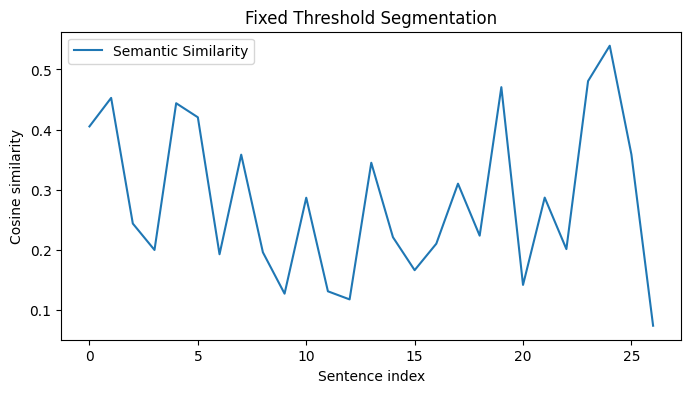

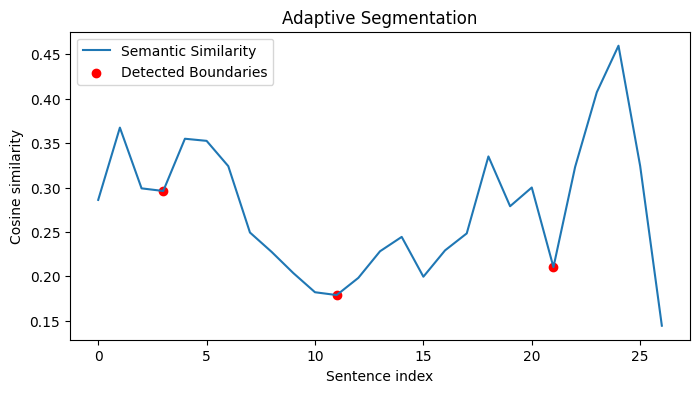

Fixed: 8 segments 
Adaptive: 3 segments
Fixed coherence: 0.280
Adaptive coherence: 0.215


In [130]:
sample_text = episode

segments_fixed, sim_fixed = segment_fixed_threshold(sample_text, model)
segments_adapt, sim_adapt, peaks = segment_adaptive(sample_text, model)

plot_similarity_curve(sim_fixed, title="Fixed Threshold Segmentation")
plot_similarity_curve(sim_adapt, peaks, title="Adaptive Segmentation")

print(f"Fixed: {len(segments_fixed)} segments \nAdaptive: {len(segments_adapt)} segments")
print(f"Fixed coherence: {segment_coherence(segments_fixed, model):.3f}")
print(f"Adaptive coherence: {segment_coherence(segments_adapt, model):.3f}")


In [121]:

print("\n" + "="*30)
print("PODCAST ADAPT_SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments_adapt):
    print(f"--- SEGMENT {i+1} ---\n")
    print(segment)
    if i > 5:
        break
    print("\n" + "-"*20 + "\n")

print("\n" + "="*30)
print("PODCAST FIXED_SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments_fixed):
    print(f"--- SEGMENT {i+1} ---\n")
    print(segment)
    if i > 5:
        break
    print("\n" + "-"*20 + "\n")


PODCAST ADAPT_SEGMENTATION RESULTS

--- SEGMENT 1 ---

 I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me. My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out. Hi I hope you're having a fantastic week everyone. Thank you to all those who tuned in last week and listen to the first song from the Keystone album Way to Know Where. I'm very proud of the whole album and how it's turned out and the response that we're getting through iTunes and Spotify and all those kind of other places and etc. So I do have some new music that is purely my own coming very soon and that is in the works. I promise you. In the meantime I'm going to keep on delivering some of the Keystone Chunes. So week two and I'm also honing my skills 

### 3. Testing segmentation with `TextTiling Algorithm`

In [137]:
# --- Model Loading ---
# We load both models globally to be efficient.

# Model 1: For splitting text into clean sentences
print("Loading 'sat-3l-sm' (wtpsplit) model...")
sat_model = SaT("sat-3l-sm")

# Model 2: For getting sentence embeddings
print("Loading 'all-mpnet-base-v2' (embedding) model...")
embed_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# Move models to GPU if available
try:
    if torch.cuda.is_available():
        print("CUDA available. Moving models to GPU.")
        sat_model.to("cuda")
        sat_model.half()
        embed_model.to("cuda")
    else:
        print("Running on CPU.")
except Exception as e:
    print(f"GPU setup failed: {e}")

# --- TextTiling Algorithm Functions (from paper) ---

def block_comparison_score(embs_stack, k=10): # <-- PARAMETER RENAMED
    """
    Implements the block comparison from TextTiling.
    Calculates similarity score for each "gap" between sentences.
    
    Args:
        embs_stack (torch.Tensor): A 2D Tensor of (num_sentences, emb_dim).
                                   This is PRE-STACKED.
        k (int): The block size (number of sentences to compare on
                 either side of the gap).
    
    Returns:
        list[float]: A list of similarity scores.
    """
    if len(embs_stack) < k * 2:
        # Not enough sentences to compare
        return []
        
    scores = []
    
    # *** FIX IS HERE ***
    # The 'embs_stack' variable IS ALREADY the stacked tensor.
    # The line `torch.stack(embeddings)` was removed.
    
    # Iterate from the first possible gap (after k sentences)
    # to the last possible gap (before k sentences from the end)
    for i in range(k, len(embs_stack) - k):
        # Gap is between sentence (i) and (i+1)
        
        # Block before: k sentences ending at i
        block_before = embs_stack[i-k : i]
        
        # Block after: k sentences starting at i+1
        block_after = embs_stack[i+1 : i+k+1]
        
        # Pool the embeddings (average) to get a topic vector
        pool_before = torch.mean(block_before, dim=0)
        pool_after = torch.mean(block_after, dim=0)
        
        # Calculate cosine similarity
        sim = util.cos_sim(pool_before, pool_after).item()
        scores.append(sim)
        
    return scores

def depth_score(timeseries):
    """
    Calculates the "depth" of each valley (potential break).
    A deep valley means a significant topic change.
    (This function is a direct implementation from the paper's core.py)
    """
    depth_scores = []
    for i in range(1, len(timeseries) - 1):
        left, right = i - 1, i + 1
        while left > 0 and timeseries[left - 1] > timeseries[left]:
            left -= 1
        while (
            right < (len(timeseries) - 1) and timeseries[right + 1] > timeseries[right]
        ):
            right += 1
        
        # Score is the sum of the "cliffs" on either side
        depth = (timeseries[left] - timeseries[i]) + (timeseries[right] - timeseries[i])
        depth_scores.append(depth)
    return depth_scores

def smooth(timeseries, n=2, s=1):
    """
    Applies a simple moving average filter.
    (This function is from the paper's core.py)
    """
    if not timeseries:
        return []
    smoothed_timeseries = timeseries[:]
    for _ in range(n):
        for index in range(len(smoothed_timeseries)):
            neighbours = smoothed_timeseries[
                max(0, index - s) : min(len(timeseries) - 1, index + s) + 1
            ]
            smoothed_timeseries[index] = sum(neighbours) / len(neighbours)
    return smoothed_timeseries

def get_local_maxima(array):
    """
    Finds local maxima (peaks) in a list.
    (This function is from the paper's core.py)
    """
    local_maxima_indices = []
    local_maxima_values = []
    for i in range(1, len(array) - 1):
        if array[i - 1] < array[i] and array[i] > array[i + 1]:
            local_maxima_indices.append(i)
            local_maxima_values.append(array[i])
    return local_maxima_indices, local_maxima_values

# --- Main Segmentation Function ---

def find_topical_segments(
    text, 
    k=5, 
    min_sentence_len=4,
    smooth_passes=1, 
    smooth_window=1, 
    threshold_factor=0.6
):
    """
    Combines all steps into the full hybrid pipeline.
    
    Args:
        text (str): The full podcast transcript.
        k (int): The block size for TextTiling.
        min_sentence_len (int): Filter out sentences shorter than this.
        smooth_passes (int): Number of smoothing passes.
        smooth_window (int): Window size for smoothing.
        threshold_factor (float): Threshold for break detection, as a
                                  factor of the max depth score.
    
    Returns:
        list[str]: The final list of topic segments.
        dict: A dictionary of intermediate scores for plotting.
    """
    
    # --- Step 1: Clean sentences with wtpsplit ---
    print("\n--- 1. Cleaning text with wtpsplit ---")
    sents = sat_model.split(text, do_paragraph_segmentation=False)
    print(f"Found {len(sents)} raw sentences.")

    # --- Step 2: Pre-process and Filter (CRITICAL) ---
    # This is from the paper: filter out very short,
    # non-semantic "noise" sentences.
    original_sents = sents
    sents = [s.strip() for s in sents if len(s.split()) > min_sentence_len]
    print(f"Filtered down to {len(sents)} sentences (>{min_sentence_len} words).")
    
    if len(sents) < k * 2:
        print("Not enough sentences to perform segmentation.")
        return [" ".join(original_sents)], {}
    
    # --- Step 3: Get Embeddings ---
    print("\n--- 2. Calculating Embeddings ---")
    embs = embed_model.encode(
        sents, 
        convert_to_tensor=True, 
        show_progress_bar=True
    )

    # --- Step 4: Run TextTiling Algorithm ---
    print("\n--- 3. Running TextTiling Algorithm ---")
    
    # 4a. Get block comparison scores
    sim_scores = block_comparison_score(embs, k=k) # 'embs' is already a stack
    
    # 4b. Smooth the scores
    smooth_scores = smooth(sim_scores, n=smooth_passes, s=smooth_window)
    
    # 4c. Calculate "depth" of valleys
    depth_scores = depth_score(smooth_scores)
    
    print(f"Calculated {len(sim_scores)} block similarity scores.")
    print(f"Calculated {len(depth_scores)} depth scores.")

    # --- Step 5: Find Breakpoints (Thresholding) ---
    print("\n--- 4. Finding Breakpoints ---")
    
    # Find the peaks of the depth scores
    local_maxima_indices, local_maxima_values = get_local_maxima(depth_scores)
    
    if not local_maxima_values:
        print("No significant breaks found.")
        return [" ".join(original_sents)], {}

    # Adaptive threshold:
    # A break must be at least 60% as "deep" as the deepest break.
    threshold = threshold_factor * max(local_maxima_values)
    
    # Find all breaks that pass the threshold
    break_indices = [
        local_maxima_indices[i] 
        for i, val in enumerate(local_maxima_values) 
        if val > threshold
    ]
    
    print(f"Found {len(local_maxima_indices)} potential breaks.")
    print(f"Max depth score: {max(local_maxima_values):.4f}")
    print(f"Calculated threshold: {threshold:.4f}")
    print(f"Filtered down to {len(break_indices)} final breaks.")

    # --- Step 6: Map indices and create segments ---
    print("\n--- 5. Creating Final Segments ---")
    
    # This maps the depth_score indices back to the original sentence indices.
    # A depth_score index 'idx' corresponds to a sim_score index 'idx+1'.
    # A sim_score index 'idx' corresponds to a sentence gap 'idx+k'.
    final_break_indices = [k + idx + 1 for idx in break_indices]
    
    # Create the final list of "slice" points
    idx_list = sorted(list(set([0] + final_break_indices + [len(sents)])))
    
    segments = []
    for i in range(len(idx_list) - 1):
        start = idx_list[i]
        end = idx_list[i+1]
        segments.append(" ".join(sents[start:end]))
        
    # Data for plotting
    plot_data = {
        'sim_scores': sim_scores,
        'smooth_scores': smooth_scores,
        'depth_scores': depth_scores,
        'threshold': threshold,
        'breaks': break_indices,
        'score_x_axis': list(range(len(depth_scores))),
        'break_x_axis': break_indices
    }
        
    return segments, plot_data

def plot_segmentation_scores(plot_data, k=5):
    """
    Uses matplotlib to visualize the algorithm's scores.
    """
    if not plot_data:
        print("\nNo plot data to show.")
        return
        
    print("\nGenerating plot...")
    
    sim_scores = plot_data['sim_scores']
    smooth_scores = plot_data['smooth_scores']
    depth_scores = plot_data['depth_scores']
    threshold = plot_data['threshold']
    break_x_axis = plot_data['break_x_axis']

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))
    fig.suptitle('Hybrid TextTiling Segmentation Analysis', fontsize=16)

    # --- Plot 1: Similarity Scores ---
    # X-axis needs to be offset to align with gaps
    sim_x_axis = [i + k for i in range(len(sim_scores))]
    smooth_x_axis = [i + k for i in range(len(smooth_scores))]

    ax1.plot(sim_x_axis, sim_scores, 'b-', label='Raw Similarity')
    ax1.plot(smooth_x_axis, smooth_scores, 'r-', linewidth=2, label='Smoothed Similarity')
    ax1.set_ylabel('Similarity (Higher is similar)')
    ax1.set_title('Block Similarity Scores (Valleys = Topic Breaks)')
    ax1.legend()
    ax1.grid(True, linestyle=':')

    # --- Plot 2: Depth Scores ---
    # X-axis needs to be offset to align with gaps
    depth_x_axis = [i + k + 1 for i in range(len(depth_scores))]
    
    ax2.plot(depth_x_axis, depth_scores, 'g-', linewidth=2, label='Valley Depth Score')
    ax2.plot(
        depth_x_axis, 
        [threshold] * len(depth_scores), 
        'r--', 
        label=f'Threshold ({threshold:.2f})'
    )
    
    # Plot the breaks we found
    break_points_x = [depth_x_axis[i] for i in break_x_axis]
    break_points_y = [depth_scores[i] for i in break_x_axis]
    ax2.plot(break_points_x, break_points_y, 'kx', markersize=10, mew=3, label='Final Topic Break')
    
    ax2.set_xlabel('Sentence Gap Index')
    ax2.set_ylabel('Depth Score (Higher is better break)')
    ax2.set_title('Depth Score Analysis (Peaks = Topic Breaks)')
    ax2.legend()
    ax2.grid(True, linestyle=':')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig("segmentation_plot.png")
    print("Plot saved to segmentation_plot.png")
    # To display the plot in a notebook, you might use plt.show()
    plt.show()


Loading 'sat-3l-sm' (wtpsplit) model...
Loading 'all-mpnet-base-v2' (embedding) model...
CUDA available. Moving models to GPU.



--- 1. Cleaning text with wtpsplit ---
Found 32 raw sentences.
Filtered down to 25 sentences (>3 words).

--- 2. Calculating Embeddings ---


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


--- 3. Running TextTiling Algorithm ---
Calculated 17 block similarity scores.
Calculated 15 depth scores.

--- 4. Finding Breakpoints ---
Found 2 potential breaks.
Max depth score: 0.6957
Calculated threshold: 0.3478
Filtered down to 1 final breaks.

--- 5. Creating Final Segments ---

HYBRID TEXTTILING SEGMENTATION RESULTS

--- TOPICAL SEGMENT 1 ---

I'm Simon Shapiro and this is Sing Out Speak Out. Here I give you the philosophies, ideas and songs I've been working on for many years but until now I've shared just too few of because I've been afraid of you and worse I've been afraid of me. My will to connect with you and share the best of me has grown greater than any fear and that's why I am compelled to Sing Out Speak Out. Hi I hope you're having a fantastic week everyone. Thank you to all those who tuned in last week and listen to the first song from the Keystone album Way to Know Where. I'm very proud of the whole album and how it's turned out and the response that we're getting

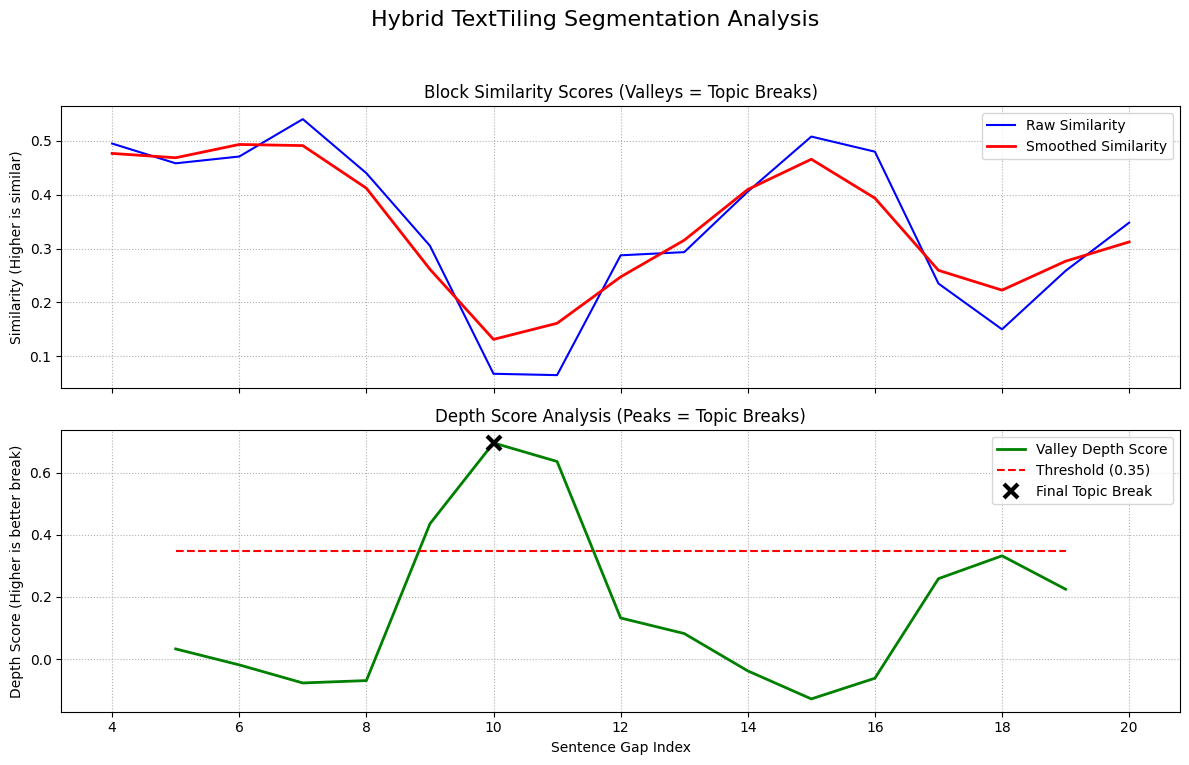

In [138]:
# --- A. Sample Data (Noisier) ---
# This text includes short interjections that our
# old method would fail on, but this method should handle.
sample_transcript = (
    "Welcome to 'TechForward', I'm your host, Alex. "
    "Today we're diving deep into the world of artificial intelligence. "
    "It's a field that's moving at lightning speed. "
    "We're seeing AI that can generate photorealistic video. "
    "But what does this mean for artists? "
    "Sarah, you're an expert in AI ethics, what's your take? "
    "Well Alex, it's a valid concern, but I see it more as a tool for augmentation, not replacement. "
    "Right. " # NOISE
    "Think of it like the synthesizer in music. "
    "It didn't replace musicians, it created new genres.\n"
    "That's a great point. Okay. " # NOISE
    "Let's switch gears a bit. "
    "I want to talk about hardware. "
    "None of this amazing AI would be possible without the incredible advancements in GPU technology. "
    "These new tensor cores are specifically designed for matrix multiplication. "
    "It's fascinating how software and hardware are co-evolving.\n"
    "I see. " # NOISE
    "Speaking of hardware, I've just been testing the new 'QuantumByte' laptop. "
    "It's got one of these new chips. "
    "The battery life, however, is another story. "
    "That's always the trade-off, isn't it? "
    "For our listeners thinking of upgrading, I'd say wait for the second-gen reviews.\n"
    "Absolutely. Okay, before we wrap up, let's look at what's coming next week. "
    "We'll be interviewing the CEO of 'GreenSolar', a company revolutionizing home energy storage. "
    "It's a bold claim, and we're going to dig into the science behind it. Thanks for tuning in."
)

# --- B. Set Hyperparameters ---
# We use a smaller 'k' because our text is short.
# For a long podcast, the paper's default of k=15 is better.
K_BLOCK_SIZE = 4           # How many sentences in a block
MIN_SENTENCE_LEN = 3     # Filter sentences shorter than 3 words
SMOOTH_PASSES = 1        # Number of smoothing passes
SMOOTH_WINDOW = 1        # Window for smoothing
THRESHOLD_FACTOR = 0.5   # 0.6 = break must be 60% of max depth

# --- C. Run Full Pipeline ---
segments, plot_data = find_topical_segments(
    episode,
    k=K_BLOCK_SIZE,
    min_sentence_len=MIN_SENTENCE_LEN,
    smooth_passes=SMOOTH_PASSES,
    smooth_window=SMOOTH_WINDOW,
    threshold_factor=THRESHOLD_FACTOR
)
# --- D. Print Results ---
print("\n" + "="*30)
print("HYBRID TEXTTILING SEGMENTATION RESULTS")
print("="*30 + "\n")

for i, segment in enumerate(segments):
    print(f"--- TOPICAL SEGMENT {i+1} ---\n")
    print(segment.strip())
    print("\n" + "-"*20 + "\n")
# --- E. Plot Results ---
if 'plt' in globals():
    plot_segmentation_scores(plot_data, k=K_BLOCK_SIZE)
else:
    print("\nMatplotlib not installed. Skipping plot.")
    print("To see the plot, run: pip install matplotlib")

<p style="color:red"><strong><em>Overall, the third method for segmentation with <code>block_comparison_score</code> and <code>depth_score</code> does much better job at segmenting the transcript with better precision and and much much more robust to noise(e.g. [music], 'brilliant', 'aah', 'let me know'...)</em></strong></p> 

# Evaluation and further testing

### Evaluate on Multiple Episodes

,episode_id,epTitle,podTitle,num_sentences,fixed_segments,adaptive_segments,fixed_coherence,adaptive_coherence,overlapPropDuration,numMainSpeakers,avgTurnDuration
0,0,Best of SingOut SpeakOut No.3,SingOut SpeakOut,8,8,1,0,0.169082,0.000000,1.0,60.000000
1,1,It's All Gone,SingOut SpeakOut,5,5,1,0,0.115270,0.000000,3.0,120.053333
2,2,Today Is Yesterday,SingOut SpeakOut,20,20,3,0,0.226153,0.001847,4.0,30.400000
3,3,Saturn Return,SingOut SpeakOut,28,28,4,0,0.234314,0.005649,3.0,39.683333
4,4,Quarterlife Crisis,SingOut SpeakOut,19,19,3,0,0.247114,0.035983,3.0,33.978667


<Axes: title={'center': 'Overlap vs. Coherence'}, xlabel='overlapPropDuration', ylabel='adaptive_coherence'>

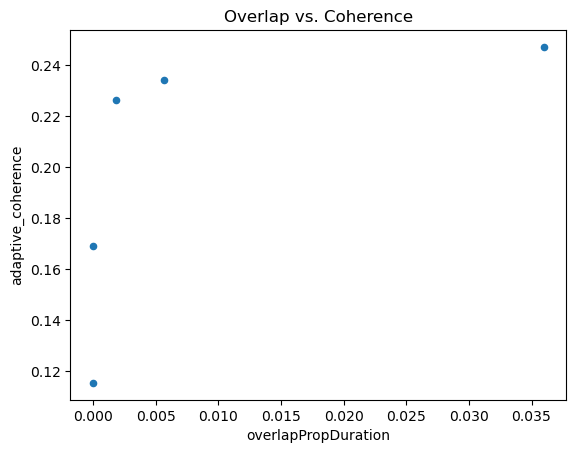

In [8]:
results = []
for i, row in dataset_sample.head(5).iterrows():
    text = row["transcript"]
    if not isinstance(text, str) or len(text.split()) < 50:
        continue

    seg_fixed, sim_fixed = segment_fixed_threshold(text, model)
    seg_adapt, sim_adapt, peaks = segment_adaptive(text, model)
    results.append({
        "episode_id": i,
        "epTitle": row["epTitle"],
        "podTitle": row["podTitle"],
        "num_sentences": len(sent_tokenize(text)),
        "fixed_segments": len(seg_fixed),
        "adaptive_segments": len(seg_adapt),
        "fixed_coherence": segment_coherence(seg_fixed, model),
        "adaptive_coherence": segment_coherence(seg_adapt, model),
        "overlapPropDuration": row.get("overlapPropDuration", np.nan),
        "numMainSpeakers": row.get("numMainSpeakers", np.nan),
        "avgTurnDuration": row.get("avgTurnDuration", np.nan)
    })
    
results_df = pd.DataFrame(results)
display(results_df)

results_df.plot.scatter(x="overlapPropDuration", y="adaptive_coherence", title="Overlap vs. Coherence")

### Prototype Topic Modeling and Graph Analysis

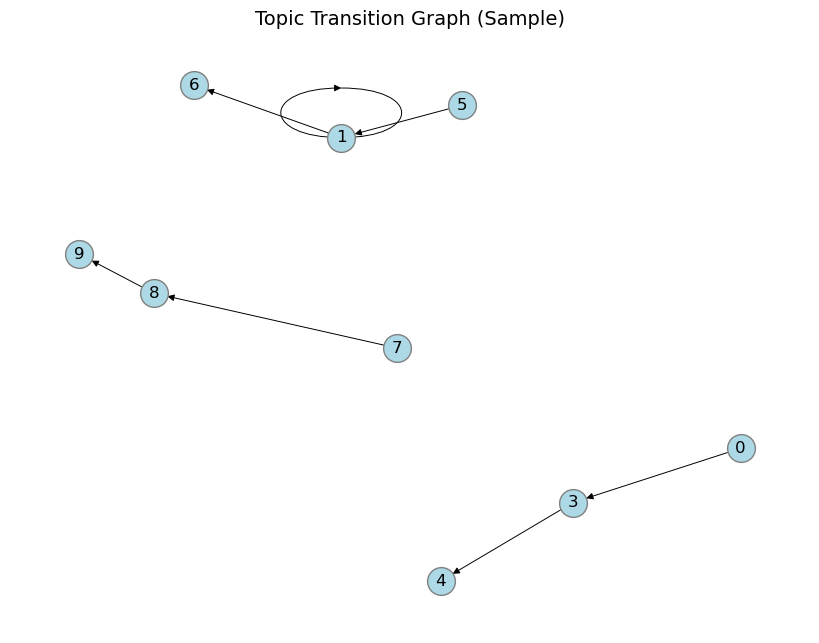

In [ ]:
vectorizer = CountVectorizer(ngram_range=(1, 2), stop_words="english")
kmeans = KMeans(n_clusters=10, random_state=42) #maybe HDBSCAN
topic_model = BERTopic(hdbscan_model=kmeans, vectorizer_model=vectorizer)

segments_dataset = pd.DataFrame({
    "episode_id": results_df["episode_id"].repeat(results_df["adaptive_segments"]).reset_index(drop=True),
    "text": [seg for ep in dataset_sample.head(5)["transcript"].apply(lambda x: segment_adaptive(x, model)[0]) for seg in ep]
})
topics, probs = topic_model.fit_transform(segments_dataset["text"])
segments_dataset["topic"] = topics

# Build topic graph
edges = []
for eid, group in segments_dataset.groupby("episode_id"):
    seq = list(group["topic"])
    for a,b in zip(seq[:-1], seq[1:]): edges.append((a,b))
G = nx.DiGraph()
for e in edges:
    if G.has_edge(e[0], e[1]):
        G[e[0]][e[1]]["weight"] += 1
    else:
        G.add_edge(e[0], e[1], weight=1)
    
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
weights = [max(0.7, min(G[u][v]["weight"]/2, 3)) for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=400, width=weights, edgecolors="gray")
plt.title("Topic Transition Graph (Sample)", fontsize=14)
plt.show()

### Adaptive segmentation on 5 episodes

##### Load 5 episodes

In [10]:
# Selecting first 5 episodes
num_episodes = 5
dataset_sample_subset = dataset_sample.head(num_episodes)

##### Adaptive Segmentation & Similarity Curves

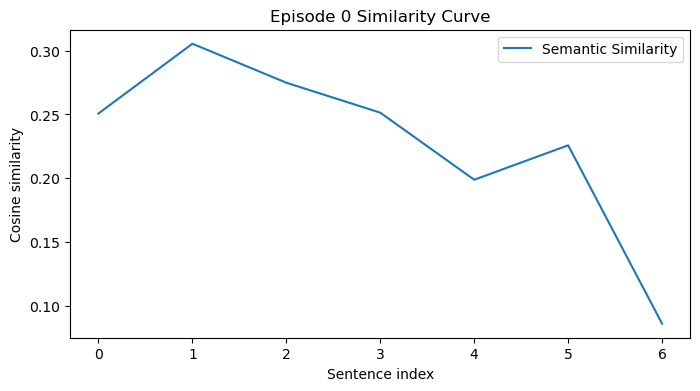

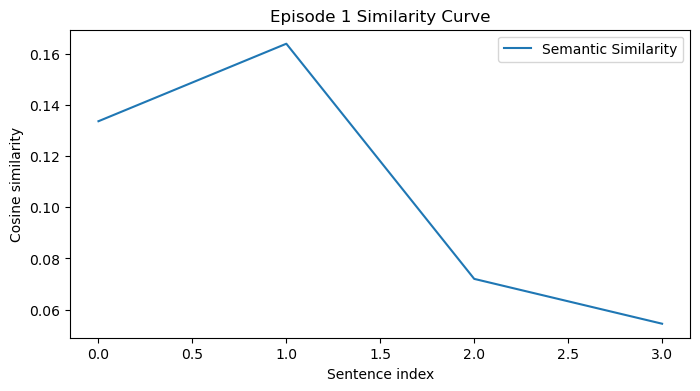

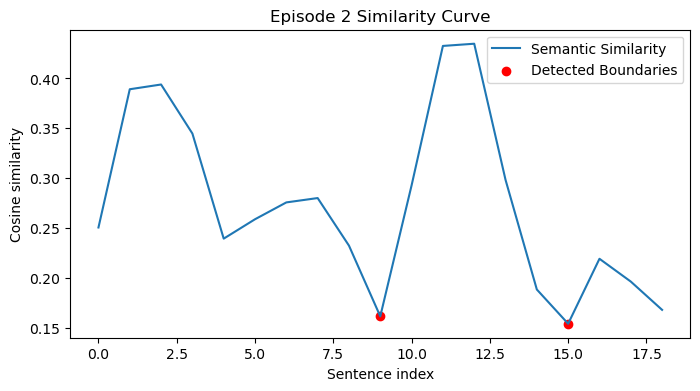

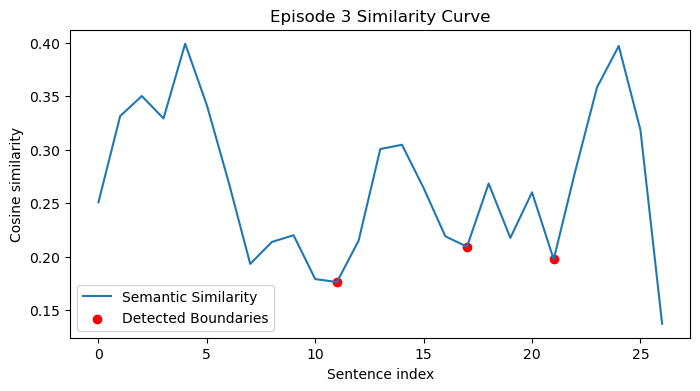

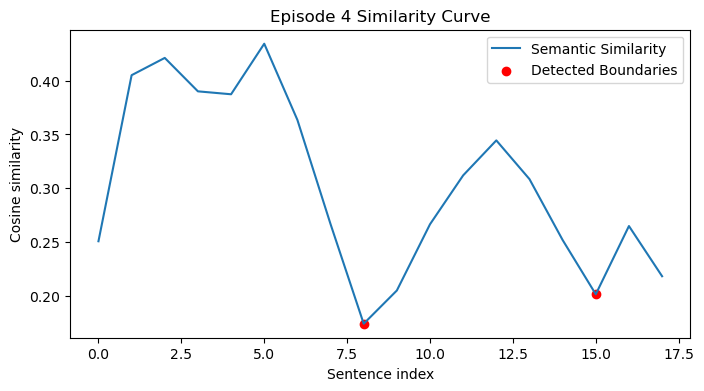

Total segments extracted: 12


,episode_id,epTitle,podTitle,segment_text
0,0,Best of SingOut SpeakOut No.3,SingOut SpeakOut,I'm Simon Shapiro and this is Sing Out Speak ...
1,1,It's All Gone,SingOut SpeakOut,I'm Simon Shapiro and this is Sing Out Speak ...
2,2,Today Is Yesterday,SingOut SpeakOut,I'm Simon Shapiro and this is Sing Out Speak ...
3,2,Today Is Yesterday,SingOut SpeakOut,So as I'm introducing songs to the Kiss Tone a...
4,2,Today Is Yesterday,SingOut SpeakOut,Without further adieu this is track four from ...


In [11]:
# Sentence transformer model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Adaptive segmentation and similarity curves
segments_list = []

for i, row in dataset_sample_subset.iterrows():
    transcript = row["transcript"]
    if not isinstance(transcript, str) or len(transcript.split()) < 50:
        continue
    
    # Apply adaptive segmentation
    segments, sim_scores, peaks = segment_adaptive(transcript, model)
    
    # Plot similarity curve for each episode
    plt.figure(figsize=(8,4))
    plt.plot(sim_scores, label="Semantic Similarity")
    if len(peaks) > 0:
        plt.scatter(peaks, np.array(sim_scores)[peaks], color='red', label='Detected Boundaries')
    plt.title(f"Episode {i} Similarity Curve")
    plt.xlabel("Sentence index")
    plt.ylabel("Cosine similarity")
    plt.legend()
    plt.show()
    
    # Save segments in list
    for seg in segments:
        segments_list.append({
            "episode_id": i,
            "epTitle": row.get("epTitle", f"Episode {i}"),
            "podTitle": row.get("podTitle", "Unknown Podcast"),
            "segment_text": seg
        })

# Convert to DataFrame
segments_df = pd.DataFrame(segments_list)
print(f"Total segments extracted: {len(segments_df)}")
segments_df.head()

##### Topic Modeling with BERTopic

In [12]:
vectorizer = CountVectorizer(ngram_range=(1,2), stop_words="english")
kmeans = KMeans(n_clusters=10, random_state=42)
topic_model = BERTopic(hdbscan_model=kmeans, vectorizer_model=vectorizer)

# Fit topic model
topics, probs = topic_model.fit_transform(segments_df["segment_text"])
segments_df["topic"] = topics

# Preview topics
topic_model.get_topic_info().head()

,Topic,Count,Name,Representation,Representative_Docs
0,0,2,0_ive_day_sing speak_speak,"[ive, day, sing speak, speak, sing, youre, afr...",[ I'm Simon Shapiro and this is Sing Out Speak...
1,1,2,1_music_music music_dont way_way,"[music, music music, dont way, way, dont, toda...",[So as I'm introducing songs to the Kiss Tone ...
2,2,1,2_believe_fantasy_believe believe_ive,"[believe, fantasy, believe believe, ive, just,...",[ I'm Simon Shapiro and this is Sing Out Speak...
3,3,1,3_ive_im_week_keystone,"[ive, im, week, keystone, album, ive afraid, a...",[ I'm Simon Shapiro and this is Sing Out Speak...
4,4,1,4_maybe_track_actually_people,"[maybe, track, actually, people, winehouse, wa...",[Write a comment maybe you could do some tips ...


##### Topic Transition Graph

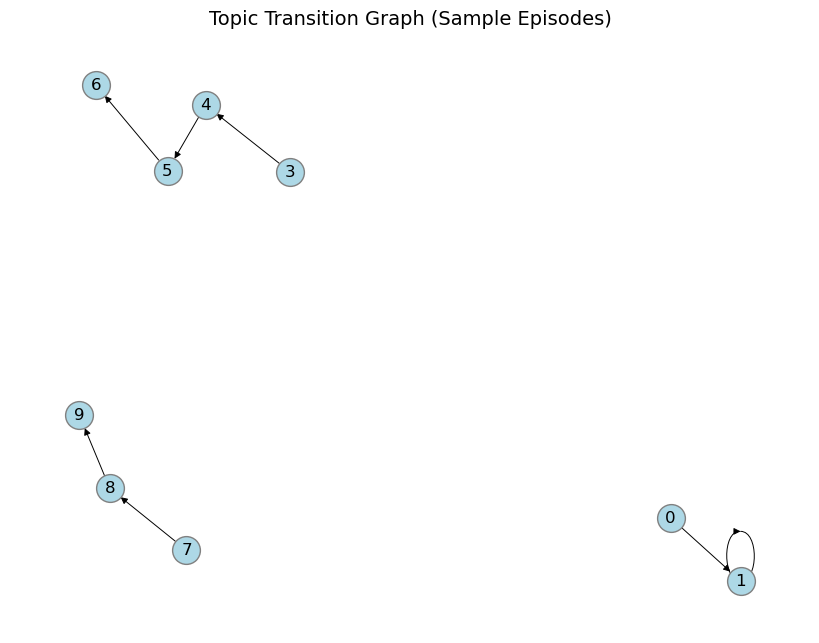

In [13]:
edges = []
for eid, group in segments_df.groupby("episode_id"):
    seq = list(group["topic"])
    for a,b in zip(seq[:-1], seq[1:]):
        edges.append((a,b))

G = nx.DiGraph()
for e in edges:
    if G.has_edge(e[0], e[1]):
        G[e[0]][e[1]]["weight"] += 1
    else:
        G.add_edge(e[0], e[1], weight=1)

# Draw the graph
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
weights = [max(0.7, min(G[u][v]["weight"]/2, 3)) for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=400, width=weights, edgecolors="gray")
plt.title("Topic Transition Graph (Sample Episodes)", fontsize=14)
plt.show()